In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
import corner
from scipy import integrate, interpolate
import emcee

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

In [4]:
savedir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z=0.72882224/cloudy_fits/'

Obtain the UVB grid from FG20

In [5]:
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb('', 'fg20_galaxy.ascii')

Fetch the SED at $z=1$

In [6]:
z_test = 1

In [7]:
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

Specify $N_{\mathrm{HI}}$ grid points and get corresponding filenames

In [8]:
logN_HI_min = 12
logN_HI_max = 17
logN_HI_step = 0.25

logN_HI_arr = np.arange(logN_HI_min, logN_HI_max+logN_HI_step, logN_HI_step)

In [9]:
file_list = create_grid_file_list(logN_HI_arr)

Specify grid points for densities and metallicities

In [10]:
log_hdens_min = -5
log_hdens_max = 1
log_hdens_step = 0.25

log_hdens_arr = np.arange(log_hdens_min, log_hdens_max+log_hdens_step, log_hdens_step)
logU_arr = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_arr))

In [11]:
log_metals_min = -3
log_metals_max = 1
log_metals_step = 0.25

log_metals_arr = np.arange(log_metals_min, log_metals_max+log_metals_step, log_metals_step)

Load the final grid

In [12]:
pkl_file = open(rootdir+'final_grid.pkl', 'rb')
species_logN_samples = pickle.load(pkl_file)
pkl_file.close()

Interpolate this grid

In [13]:
species_logN_interp = {}

for s in list(species_logN_samples.keys()):
    
    species_logN_samples[s][species_logN_samples[s]==-np.inf] = -99
    
    species_logN_interp[s] = RegularGridInterpolator((logN_HI_arr, log_hdens_arr, log_metals_arr), 
                                                     species_logN_samples[s])

Enter measurements for species

In [14]:
logN_dict = {'HI':'16.64, -0.01, +0.01',
            'CII':'<12.74',
            'CIII':'13.37, -0.07, +0.07',
            'CIV':'<12.86',
            'NII':'<13.52',
            'NIII':'<12.92',
            'NIV':'<12.53',
            'OII':'<12.88',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'14.42, -0.02, +0.02',
            'NeVIII':'<13.49',
            'MgII':'<11.31',
            'AlIII':'<11.83',
            'SiII':'<12.43',
            'SiIII':'<12.42',
            'SiIV':'<12.47',
            'SIV':'<12.59',
            'SV':'<12.08',
            'SVI':'<12.90',
            'FeII':'<11.67'}

Try out a new solution including sub-solar [C/O]

In [15]:
logN_HI_test = 16.4
log_hdens_test = -3.33 #-2.9  
log_metals_test = -0.1 #-2.6

In [16]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, log_metals_test, species_logN_interp)

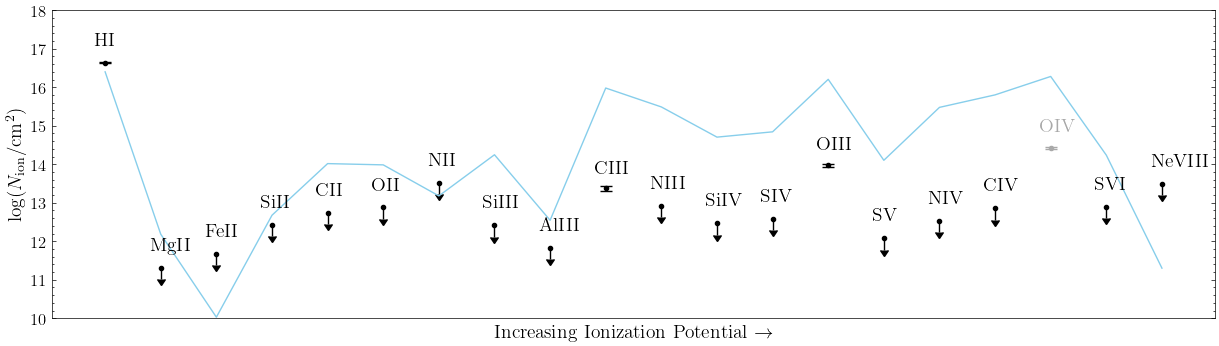

In [17]:
fig, ax = plot_column_densities_obs(logN_dict, gray_out=['OIV'])
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue')

Try fit with OIII and OIV

In [18]:
logN_OIV_OIII = 14.42-13.97
sigma_OIV_OIII = np.sqrt(0.02**2 + 0.03**2)

In [19]:
log_hdens_grid = np.linspace(log_hdens_min, log_hdens_max, 1000)

In [20]:
grid_points = np.array([[14, log_hdens, -1] for log_hdens in log_hdens_grid])

In [21]:
logN_bar_OIV_OIII = species_logN_interp['O+3'](grid_points)-species_logN_interp['O+2'](grid_points)

In [22]:
chi_sq = (logN_OIV_OIII-logN_bar_OIV_OIII)**2/sigma_OIV_OIII**2
delta_chi_sq = chi_sq-np.min(chi_sq)

In [23]:
log_hdens_best_OIV_OIII = log_hdens_grid[np.argmin(chi_sq)]
sig_log_hdens_OIV_OIII = np.abs(log_hdens_best_OIV_OIII-log_hdens_grid[np.argmin(np.abs(delta_chi_sq-1))])

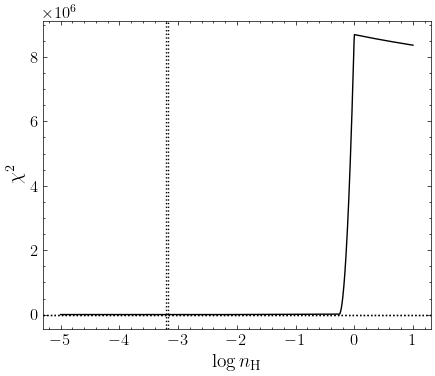

In [24]:
fig, ax = plt.subplots(1, figsize=(5,4))

ax.plot(log_hdens_grid, chi_sq)
ax.set_xlabel(r'$\log n_{\mathrm{H}}$')
ax.set_ylabel(r'$\chi^2$')
ax.axhline(0, linestyle=':')
ax.axhline(1, linestyle=':')
ax.axvline(log_hdens_best_OIV_OIII, linestyle=':')
ax.axvline(log_hdens_best_OIV_OIII+sig_log_hdens_OIV_OIII, linestyle=':')

In [25]:
log_hdens_best_OIV_OIII, sig_log_hdens_OIV_OIII

(-3.21021021021021, 0.03003003003003002)

Get upper limit on gas density using OII and OIII

$$\mathcal{L}(n_{\mathrm{n_H}}) \propto \int_{-\infty}^{\log (N_{\mathrm{OII, UL}}/N_{\mathrm{OIII}})} \mathrm{d} \log (N_{\mathrm{OII}}/N_{\mathrm{OIII}}) \exp \left(- \frac{1}{2}  \frac{(\log(N_{\mathrm{OII}}/N_{\mathrm{OIII}})-\log(\bar{N}_{\mathrm{OII}}/\bar{N}_{\mathrm{OIII}}))^2}{\sigma_{\mathrm{OII}}^2 + \sigma_{\mathrm{OIII}}^2} \right)$$

In [26]:
logN_OII_OIII = 12.88-13.97
sigma_OII_OIII = np.sqrt(0.14**2 + 0.03**2)

In [27]:
logN_bar_OII_OIII = species_logN_interp['O+'](grid_points)-species_logN_interp['O+2'](grid_points)

Text(0, 0.5, '$\\log (N_{\\mathrm{OII}/N_{\\mathrm{OIII}}})$')

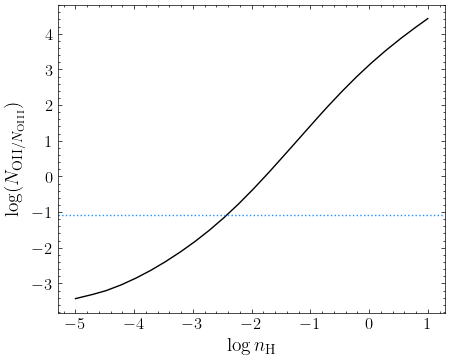

In [28]:
fig, ax = plt.subplots(1, figsize=(5,4))

ax.plot(log_hdens_grid, logN_bar_OII_OIII)
ax.axhline(logN_OII_OIII, linestyle=':', color='dodgerblue')
ax.set_xlabel(r'$\log n_{\mathrm{H}}$')
ax.set_ylabel(r'$\log (N_{\mathrm{OII}/N_{\mathrm{OIII}}})$')

In [29]:
likelihood = np.zeros(len(log_hdens_grid))

for i in range(len(log_hdens_grid)):

    x = np.arange(-99, logN_OII_OIII+.05, .05)
    chi_sq = (x-logN_bar_OII_OIII[i])**2/sigma_OII_OIII**2
    likelihood[i] = integrate.trapz(x=x, y=np.exp(-0.5*chi_sq))

In [30]:
# Sigma values taken from Gehrels 1986

cdf_1sig = 0.8413
cdf_2sig = 0.9772
cdf_3sig = 0.9987

Text(0, 0.5, '$\\mathcal{L}$')

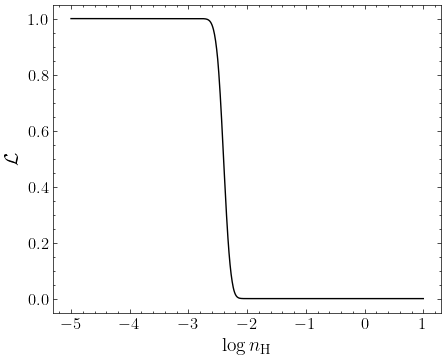

In [31]:
fig, ax = plt.subplots(1, figsize=(5,4))

ax.plot(log_hdens_grid, likelihood/np.max(likelihood))
#ax.axhline(1-cdf_3sig, linestyle=':')
ax.set_xlabel(r'$\log n_{\mathrm{H}}$')
ax.set_ylabel(r'$\mathcal{L}$')

#ax.set_xlim(-2.5, -1.5)
#ax.set_ylim(0,2*(1-cdf_3sig))

Text(0, 0.5, '$\\mathcal{L}$')

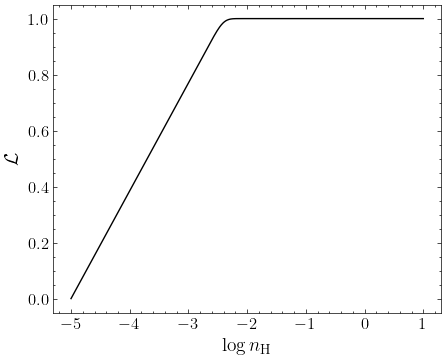

In [32]:
fig, ax = plt.subplots(1, figsize=(5,4))

ax.plot(log_hdens_grid, np.cumsum(likelihood)/np.sum(likelihood))
ax.set_xlabel(r'$\log n_{\mathrm{H}}$')
ax.set_ylabel(r'$\mathcal{L}$')

In [33]:
cdf = np.cumsum(likelihood)/np.sum(likelihood)
ppf_interp = interpolate.interp1d(x=cdf, y=log_hdens_grid, fill_value='extrapolate')

In [34]:
log_hdens_OII_OIII_2sig = ppf_interp(cdf_2sig)
log_hdens_OII_OIII_3sig = ppf_interp(cdf_3sig)

In [35]:
log_hdens_OII_OIII_2sig, log_hdens_OII_OIII_3sig

(array(-2.44224847), array(-2.27334144))

Get an upper limit to gas density using CIII and CIV

In [36]:
logN_CIV_CIII = 12.86-13.37
sigma_CIV_CIII = np.sqrt(0.14**2 + 0.07**2)

In [37]:
logN_CIV_CIII

-0.5099999999999998

In [38]:
logN_bar_CIV_CIII = species_logN_interp['C+3'](grid_points)-species_logN_interp['C+2'](grid_points)

Text(0, 0.5, '$\\log (N_{\\mathrm{CIV}}/N_{\\mathrm{CIII}})$')

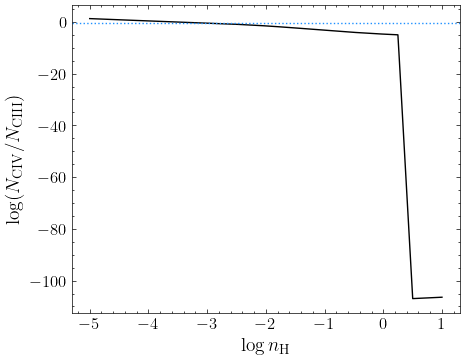

In [39]:
fig, ax = plt.subplots(1, figsize=(5,4))

ax.plot(log_hdens_grid, logN_bar_CIV_CIII)
ax.axhline(logN_CIV_CIII, linestyle=':', color='dodgerblue')
ax.set_xlabel(r'$\log n_{\mathrm{H}}$')
ax.set_ylabel(r'$\log (N_{\mathrm{CIV}}/N_{\mathrm{CIII}})$')

In [40]:
likelihood = np.zeros(len(log_hdens_grid))

for i in range(len(log_hdens_grid)):

    x = np.arange(-99, logN_CIV_CIII+.05, .05)
    chi_sq = (x-logN_bar_CIV_CIII[i])**2/sigma_CIV_CIII**2
    likelihood[i] = integrate.trapz(x=x, y=np.exp(-0.5*chi_sq))

Text(0, 0.5, '$\\mathcal{L}$')

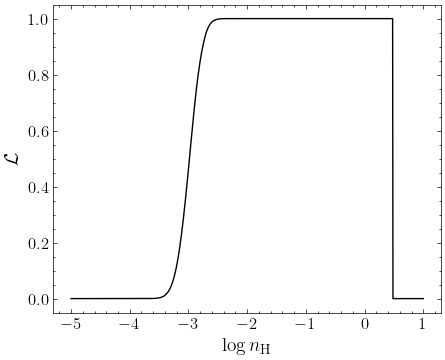

In [41]:
fig, ax = plt.subplots(1, figsize=(5,4))

ax.plot(log_hdens_grid, likelihood/np.max(likelihood))
ax.set_xlabel(r'$\log n_{\mathrm{H}}$')
ax.set_ylabel(r'$\mathcal{L}$')

In [42]:
idx = log_hdens_grid<0

Text(0, 0.5, 'CDF')

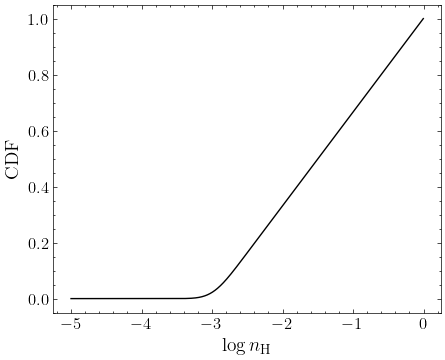

In [43]:
fig, ax = plt.subplots(1, figsize=(5,4))

ax.plot(log_hdens_grid[idx], np.cumsum(likelihood[idx])/np.sum(likelihood[idx]))
ax.set_xlabel(r'$\log n_{\mathrm{H}}$')
ax.set_ylabel(r'CDF')

In [44]:
cdf = np.cumsum(likelihood[idx])/np.sum(likelihood[idx])
ppf_interp = interpolate.interp1d(x=cdf, y=log_hdens_grid[idx], fill_value='extrapolate')

In [45]:
log_hdens_CIV_CIII_2sig = ppf_interp(1-cdf_2sig)
log_hdens_CIV_CIII_3sig = ppf_interp(1-cdf_3sig)

In [46]:
log_hdens_CIV_CIII_2sig, log_hdens_CIV_CIII_3sig

(array(-2.99633075), array(-3.28863345))

Finally, do CII and CIII

In [47]:
logN_CII_CIII = 12.74-13.37
sigma_CII_CIII = np.sqrt(0.14**2 + 0.07**2)

In [48]:
logN_CII_CIII

-0.629999999999999

In [49]:
logN_bar_CII_CIII = species_logN_interp['C+'](grid_points)-species_logN_interp['C+2'](grid_points)

Text(0, 0.5, '$\\log (N_{\\mathrm{CII}}/N_{\\mathrm{CIII}})$')

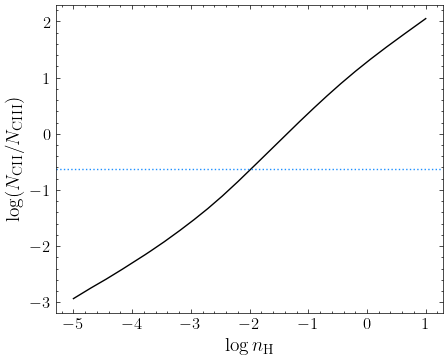

In [50]:
fig, ax = plt.subplots(1, figsize=(5,4))

ax.plot(log_hdens_grid, logN_bar_CII_CIII)
ax.axhline(logN_CII_CIII, linestyle=':', color='dodgerblue')
ax.set_xlabel(r'$\log n_{\mathrm{H}}$')
ax.set_ylabel(r'$\log (N_{\mathrm{CII}}/N_{\mathrm{CIII}})$')

In [51]:
likelihood = np.zeros(len(log_hdens_grid))

for i in range(len(log_hdens_grid)):

    x = np.arange(-99, logN_CII_CIII+.05, .05)
    chi_sq = (x-logN_bar_CII_CIII[i])**2/sigma_CII_CIII**2
    likelihood[i] = integrate.trapz(x=x, y=np.exp(-0.5*chi_sq))

Text(0, 0.5, '$\\mathcal{L}$')

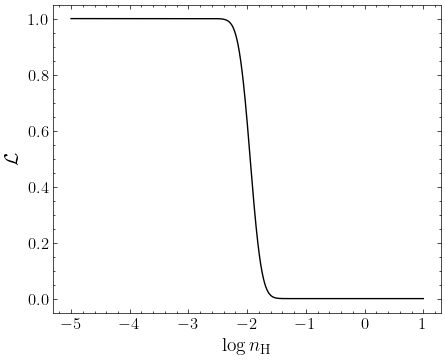

In [52]:
fig, ax = plt.subplots(1, figsize=(5,4))

ax.plot(log_hdens_grid, likelihood/np.max(likelihood))
ax.set_xlabel(r'$\log n_{\mathrm{H}}$')
ax.set_ylabel(r'$\mathcal{L}$')

Text(0, 0.5, 'CDF')

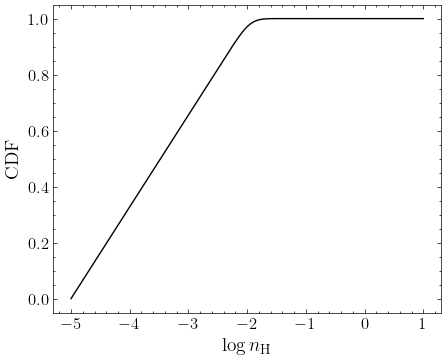

In [53]:
fig, ax = plt.subplots(1, figsize=(5,4))

ax.plot(log_hdens_grid, np.cumsum(likelihood)/np.sum(likelihood))
ax.set_xlabel(r'$\log n_{\mathrm{H}}$')
ax.set_ylabel(r'CDF')

In [54]:
cdf = np.cumsum(likelihood)/np.sum(likelihood)
ppf_interp = interpolate.interp1d(x=cdf, y=log_hdens_grid, fill_value='extrapolate')

In [55]:
log_hdens_CII_CIII_2sig = ppf_interp(cdf_2sig)
log_hdens_CII_CIII_3sig = ppf_interp(cdf_3sig)

In [56]:
log_hdens_CII_CIII_2sig, log_hdens_CII_CIII_3sig

(array(-1.96726391), array(-1.7120346))

Make the overplot

In [57]:
idx_OIV_OIII = (logN_bar_OIV_OIII>logN_OIV_OIII-sigma_OIV_OIII)&(logN_bar_OIV_OIII<logN_OIV_OIII+sigma_OIV_OIII)
idx_OII_OIII = (logN_bar_OII_OIII<logN_OII_OIII)

idx_CIV_CIII = (logN_bar_CIV_CIII<logN_CIV_CIII)
idx_CII_CIII = (logN_bar_CII_CIII<logN_CII_CIII)

In [58]:
log_hdens_OII_OIII_2sig, log_hdens_CII_CIII_2sig

(array(-2.44224847), array(-1.96726391))

In [59]:
log_hdens_CIV_CIII_2sig

array(-2.99633075)

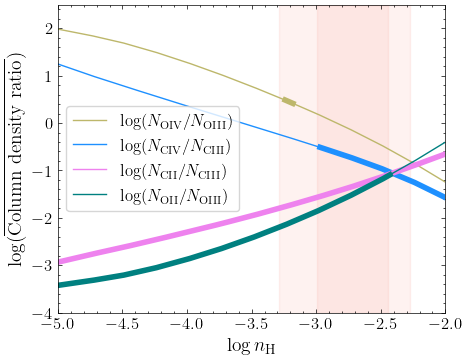

In [60]:
fig, ax = plt.subplots(1, figsize=(5,4))

ax.plot(log_hdens_grid, logN_bar_OIV_OIII, color='darkkhaki',
          label=r'$\log (N_{\mathrm{OIV}}/N_{\mathrm{OIII}})$')
ax.plot(log_hdens_grid[idx_OIV_OIII], logN_bar_OIV_OIII[idx_OIV_OIII], color='darkkhaki', lw=4)

ax.plot(log_hdens_grid, logN_bar_CIV_CIII, color='dodgerblue',
          label=r'$\log (N_{\mathrm{CIV}}/N_{\mathrm{CIII}})$')
ax.plot(log_hdens_grid[idx_CIV_CIII], logN_bar_CIV_CIII[idx_CIV_CIII], color='dodgerblue', lw=4)

ax.plot(log_hdens_grid, logN_bar_CII_CIII, color='violet',
          label=r'$\log (N_{\mathrm{CII}}/N_{\mathrm{CIII}})$')
ax.plot(log_hdens_grid[idx_CII_CIII], logN_bar_CII_CIII[idx_CII_CIII], color='violet', lw=4)

ax.plot(log_hdens_grid, logN_bar_OII_OIII, color='teal',
          label=r'$\log (N_{\mathrm{OII}}/N_{\mathrm{OIII}})$')
ax.plot(log_hdens_grid[idx_OII_OIII], logN_bar_OII_OIII[idx_OII_OIII], color='teal', lw=4)

ax.axvspan(xmin=log_hdens_CIV_CIII_2sig, xmax=log_hdens_OII_OIII_2sig, color='salmon', alpha=.1)
ax.axvspan(xmin=log_hdens_CIV_CIII_3sig, xmax=log_hdens_OII_OIII_3sig, color='salmon', alpha=.1)


ax.set_xlabel(r'$\log n_{\mathrm{H}}$')
ax.set_ylabel(r'$\log (\overline{\mathrm{Column \ density \ ratio}})$')

ax.set_xlim(-5, -2)
ax.set_ylim(-4, 2.5)
ax.legend()

# Oxygen only fit

In [18]:
# Assume solar abundance patterns throughout

def lambda_log_prior(params):
    
    # Only parameters being varied
    log_hdens, log_metals = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI_test, log_hdens, log_metals, {}])
    
    # Call the original prior function on the full set of parameters
    return log_prior(params_full)

In [19]:
def lambda_log_likelihood(params, logN_dict, species_logN_interp):

    # Only parameters being varied
    log_hdens, log_metals = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI_test, log_hdens, log_metals, {}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood(params_full, logN_dict, species_logN_interp)    

In [20]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = lambda_log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood(params, logN_dict, species_logN_interp)

Isolate the ions

In [21]:
ions_oxy = ['OII', 'OIII', 'OIV']

In [22]:
logN_dict_oxy = {ion: logN_dict[ion] for ion in ions_oxy}

In [23]:
pos = np.array([log_hdens_test, log_metals_test]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [24]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict_oxy, species_logN_interp)
)

In [25]:
#sampler.run_mcmc(pos, 500, progress=True);

In [26]:
#flat_samples_oxy = pd.DataFrame(sampler.get_chain(discard=100, flat=True), columns=['log_hdens', 'log_metals'])
#flat_samples_oxy.to_csv(savedir+'oxy_solar_flat.csv', index=False)

flat_samples_oxy = pd.read_csv(savedir+'oxy_solar_flat.csv')

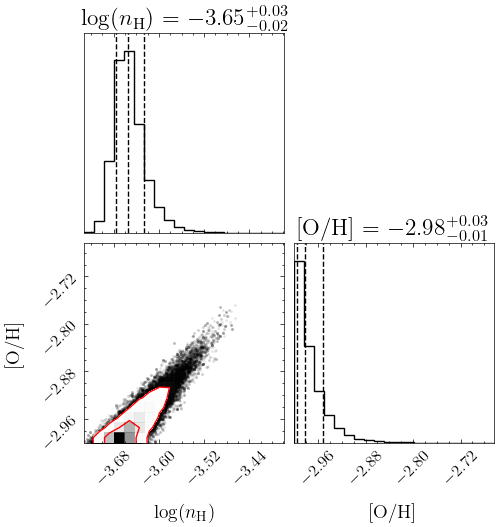

In [27]:
fig = corner.corner(
    flat_samples_oxy.loc[:, ['log_hdens', 'log_metals']], quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Now plot the best models

In [28]:
logN_dict = {'HI':'16.64, -0.01, +0.01',
            'CII':'<12.74',
            'CIII':'13.37, -0.07, +0.07',
            'CIV':'<12.86',
            'NII':'<13.52',
            'NIII':'<12.92',
            'NIV':'<12.53',
            'OII':'<12.88',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'14.42, -0.02, +0.02',
            'NeVIII':'<13.49',
            'MgII':'<11.31',
            'AlIII':'<11.83',
            'SiII':'<12.43',
            'SiIII':'<12.42',
            'SiIV':'<12.47',
            'SIV':'<12.59',
            'SV':'<12.08',
            'SVI':'<12.90',
            'FeII':'<11.67'}

In [29]:
sample_indices_oxy = np.random.randint(low=0, high=len(flat_samples_oxy), size=200)

Text(0.5, 16.5, '$[\\mathrm{O}/\\mathrm{H}] = -2.98_{-0.01}^{+0.03}$')

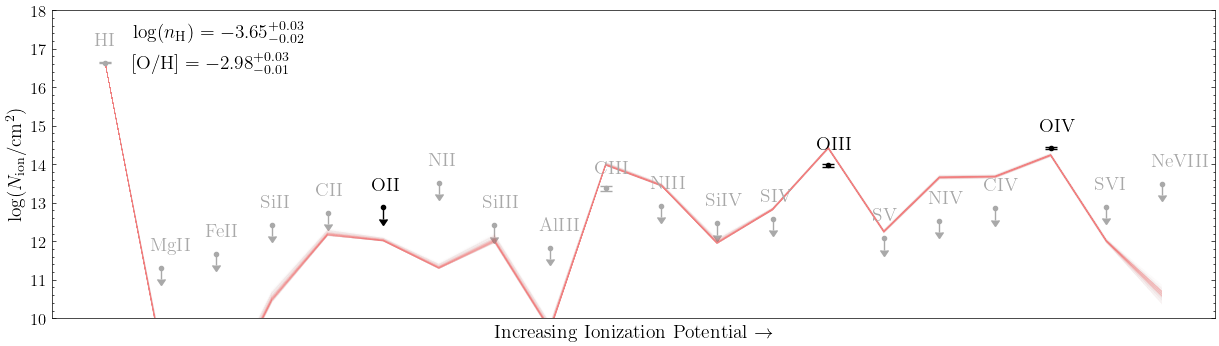

In [30]:
fig, ax = plot_column_densities_obs(logN_dict, gray_out=['HI', 'CII', 'CIII',  
                                                         'CIV', 'NII', 'NIII', 'NIV',
                                                         'NeVIII', 'MgII', 
                                                         'AlIII', 'SiII', 'SiIII', 'SiIV', 'SIV', 'SV',
                                                         'SVI', 'FeII'])

for i in range(len(sample_indices_oxy)):
    
    idx = sample_indices_oxy[i]
    flat_samples_row = flat_samples_oxy.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    
    logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens, 
                                         log_metals, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.05)

ax.text(x=0.5, y=17.3, s=r'$\log(n_\mathrm{H}) = -3.65_{-0.02}^{+0.03}$')
ax.text(x=0.5, y=16.5, s=r'$[\mathrm{O}/\mathrm{H}] = -2.98_{-0.01}^{+0.03}$')

#plt.savefig(savedir+'z=0_72882224_cloudy_oxy.pdf', dpi=300)

Exclude OIV

In [31]:
ions_oxy_re = ['OII', 'OIII']

In [32]:
logN_dict_oxy_re = {ion: logN_dict[ion] for ion in ions_oxy_re}

In [33]:
pos = np.array([log_hdens_test, log_metals_test]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [34]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict_oxy_re, species_logN_interp)
)

In [35]:
#sampler.run_mcmc(pos, 500, progress=True);

In [36]:
#flat_samples_oxy_re = pd.DataFrame(sampler.get_chain(discard=100, flat=True), columns=['log_hdens', 'log_metals'])
#flat_samples_oxy_re.to_csv(savedir+'oxy_solar_flat_re.csv', index=False)

flat_samples_oxy_re = pd.read_csv(savedir+'oxy_solar_flat_re.csv')

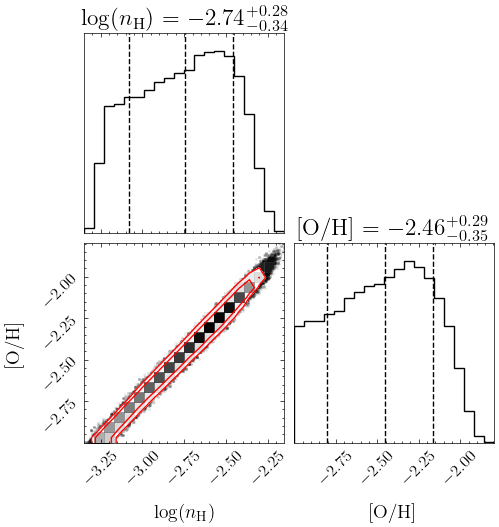

In [37]:
fig = corner.corner(
    flat_samples_oxy_re.loc[:, ['log_hdens', 'log_metals']], quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Now plot the best models

In [38]:
logN_dict = {'HI':'16.64, -0.01, +0.01',
            'CII':'<12.74',
            'CIII':'13.37, -0.07, +0.07',
            'CIV':'<12.86',
            'NII':'<13.52',
            'NIII':'<12.92',
            'NIV':'<12.53',
            'OII':'<12.88',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'14.42, -0.02, +0.02',
            'NeVIII':'<13.49',
            'MgII':'<11.31',
            'AlIII':'<11.83',
            'SiII':'<12.43',
            'SiIII':'<12.42',
            'SiIV':'<12.47',
            'SIV':'<12.59',
            'SV':'<12.08',
            'SVI':'<12.90',
            'FeII':'<11.67'}

In [39]:
sample_indices_oxy_re = np.random.randint(low=0, high=len(flat_samples_oxy_re), size=200)

Text(0.5, 16.5, '$[\\mathrm{O}/\\mathrm{H}] = -2.46_{-0.35}^{+0.29}$')

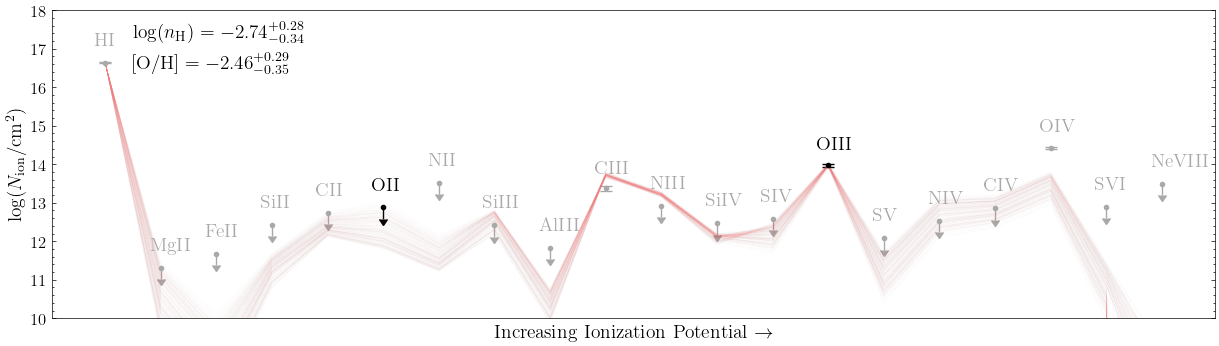

In [40]:
fig, ax = plot_column_densities_obs(logN_dict, gray_out=['HI', 'CII', 'CIII',  
                                                         'CIV', 'NII', 'NIII', 'NIV', 'OIV',
                                                         'NeVIII', 'MgII', 
                                                         'AlIII', 'SiII', 'SiIII', 'SiIV', 'SIV', 'SV',
                                                         'SVI', 'FeII'])

for i in range(len(sample_indices_oxy_re)):
    
    idx = sample_indices_oxy_re[i]
    flat_samples_row = flat_samples_oxy_re.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    
    logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens, 
                                         log_metals, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.05)

ax.text(x=0.5, y=17.3, s=r'$\log(n_\mathrm{H}) = -2.74_{-0.34}^{+0.28}$')
ax.text(x=0.5, y=16.5, s=r'$[\mathrm{O}/\mathrm{H}] = -2.46_{-0.35}^{+0.29}$')

#plt.savefig(savedir+'z=0_72882224_cloudy_oxy.pdf', dpi=300)

# $\alpha$-element only, solar abundance pattern fit

In [41]:
ions_alpha = ['MgII', 'SiII', 'OII', 'SiIII', 'SiIV', 'SIV', 'OIII', 'SV', 'SVI', 'NeVIII']

In [42]:
logN_dict_alpha = {ion: logN_dict[ion] for ion in ions_alpha}

In [43]:
pos = np.array([log_hdens_test, log_metals_test]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [44]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict_alpha, species_logN_interp)
)

In [45]:
#sampler.run_mcmc(pos, 500, progress=True);

In [46]:
#flat_samples_alpha = pd.DataFrame(sampler.get_chain(discard=100, flat=True), columns=['log_hdens', 'log_metals'])
#flat_samples_alpha.to_csv(savedir+'alpha_solar_flat.csv', index=False)

flat_samples_alpha = pd.read_csv(savedir+'alpha_solar_flat.csv')

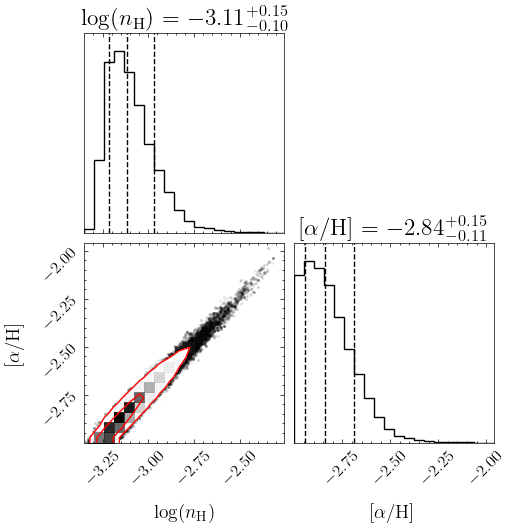

In [47]:
fig = corner.corner(
    flat_samples_alpha.loc[:, ['log_hdens', 'log_metals']], quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\alpha/\mathrm{H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Now plot the best models

In [48]:
logN_dict = {'HI':'16.64, -0.01, +0.01',
            'CII':'<12.74',
            'CIII':'13.37, -0.07, +0.07',
            'CIV':'<12.86',
            'NII':'<13.52',
            'NIII':'<12.92',
            'NIV':'<12.53',
            'OII':'<12.88',
            'OIII':'13.97, -0.03, +0.03',
            'OIV':'14.42, -0.02, +0.02',
            'NeVIII':'<13.49',
            'MgII':'<11.31',
            'AlIII':'<11.83',
            'SiII':'<12.43',
            'SiIII':'<12.42',
            'SiIV':'<12.47',
            'SIV':'<12.59',
            'SV':'<12.08',
            'SVI':'<12.90',
            'FeII':'<11.67'}

In [49]:
sample_indices_alpha = np.random.randint(low=0, high=len(flat_samples_alpha), size=200)

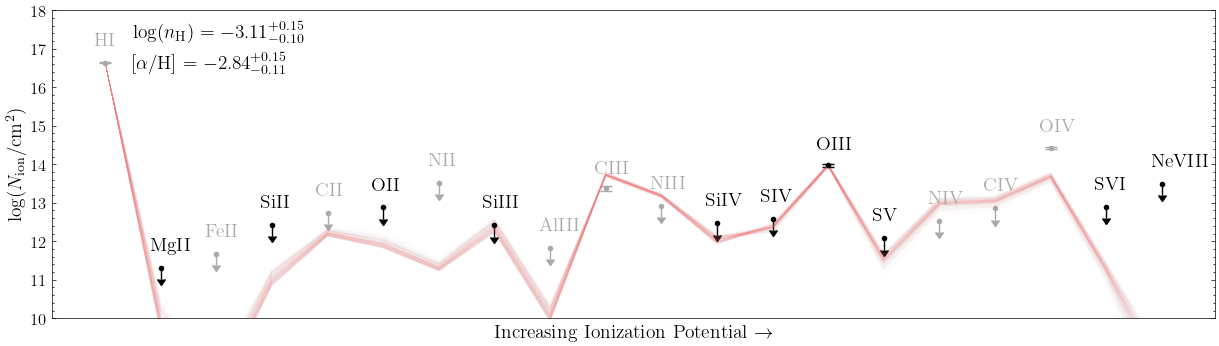

In [50]:
fig, ax = plot_column_densities_obs(logN_dict, gray_out=['HI', 'CII', 'CIII',  
                                                         'CIV', 'NII', 'NIII', 'NIV', 'OIV',
                                                         'AlIII',  'FeII'])

for i in range(len(sample_indices_alpha)):
    
    idx = sample_indices_alpha[i]
    flat_samples_row = flat_samples_alpha.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    
    logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens, 
                                         log_metals, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.05)

ax.text(x=0.5, y=17.3, s=r'$\log(n_\mathrm{H}) = -3.11_{-0.10}^{+0.15}$')
ax.text(x=0.5, y=16.5, s=r'$[\mathrm{\alpha}/\mathrm{H}] = -2.84_{-0.11}^{+0.15}$')

plt.savefig(savedir+'z=0_72882224_cloudy_alpha.pdf', dpi=300)

# Constrain [C/O]

In [51]:
ions_carb = ['CII', 'CIII', 'CIV']

In [52]:
logN_dict_carb = {ion: logN_dict[ion] for ion in ions_carb}

In [53]:
C_O_arr = np.arange(-1, 0, 0.01)

In [54]:
pdf_carb = np.exp(np.array([log_likelihood([logN_HI_test, -3.11, -2.84, {'C':C_O}], 
                                   logN_dict_carb, species_logN_interp) for C_O in C_O_arr]))

pdf_carb = pdf_carb/integrate.trapz(x=C_O_arr, y=pdf_carb)

cdf_carb = integrate.cumtrapz(x=C_O_arr, y=pdf_carb, initial=0)

In [55]:
cdf_inv_carb_interp = interpolate.interp1d(x=cdf_carb, y=C_O_arr, fill_value='extrapolate')

In [56]:
(cdf_inv_carb_interp(0.5), 
 cdf_inv_carb_interp(0.5)-cdf_inv_carb_interp(0.16), 
 cdf_inv_carb_interp(0.84)-cdf_inv_carb_interp(0.5))

(array(-0.35449597), 0.06841836952242214, 0.06784691579361674)

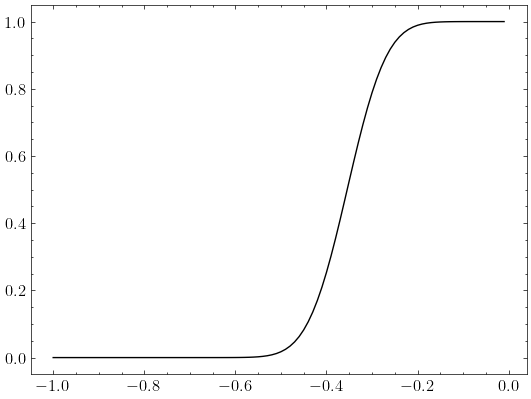

In [57]:
fig, ax = plt.subplots()

plt.plot(C_O_arr, cdf_carb)

# Constrain [N/O]

In [58]:
ions_nitro = ['NII', 'NIII', 'NIV']

In [59]:
logN_dict_nitro = {ion: logN_dict[ion] for ion in ions_nitro}

In [60]:
N_O_arr = np.arange(-3, 0, 0.01)

In [61]:
pdf_nitro = np.exp(np.array([log_likelihood([logN_HI_test, -3.11, -2.84, {'N':N_O}], 
                                   logN_dict_nitro, species_logN_interp) for N_O in N_O_arr]))

pdf_nitro = pdf_nitro/integrate.trapz(x=10**N_O_arr, y=pdf_nitro)

cdf_nitro = integrate.cumtrapz(x=10**N_O_arr, y=pdf_nitro, initial=0)

In [62]:
cdf_inv_nitro_interp = interpolate.interp1d(x=cdf_nitro, y=10**N_O_arr, fill_value='extrapolate')

Text(0, 0.5, 'PDF')

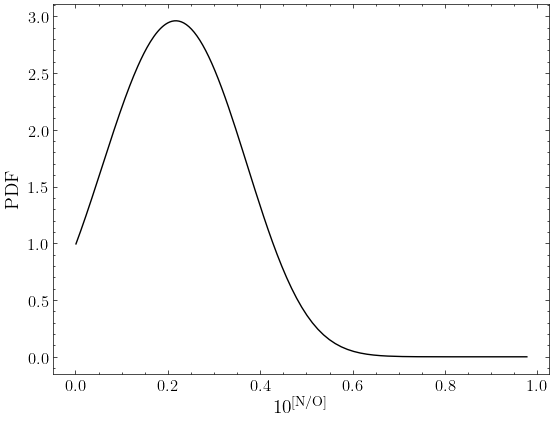

In [63]:
fig, ax = plt.subplots()

ax.plot(10**N_O_arr, pdf_nitro)

ax.set_xlabel(r'$10^{[\mathrm{N}/\mathrm{O}]}$')
ax.set_ylabel('PDF')

Text(0, 0.5, 'CDF')

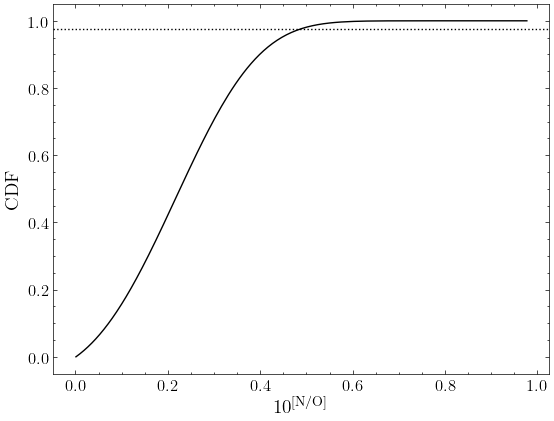

In [64]:
fig, ax = plt.subplots()

ax.plot(10**N_O_arr, cdf_nitro)
ax.axhline(0.975, linestyle=':')

ax.set_xlabel(r'$10^{[\mathrm{N}/\mathrm{O}]}$')
ax.set_ylabel('CDF')

In [65]:
np.log10(cdf_inv_nitro_interp(0.995))

-0.25063707568760396

Final overplot of best fit models

Text(16.5, 16.3, '$[\\mathrm{N}/\\mathrm{O}] < -0.25$')

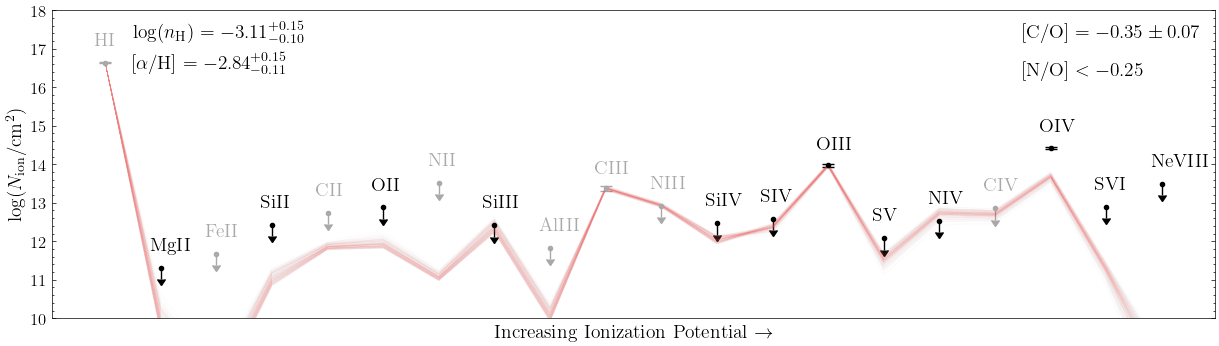

In [66]:
fig, ax = plot_column_densities_obs(logN_dict, gray_out=['HI', 'CII', 'CIII', 
                                                         'CIV', 'NII', 'NIII', 
                                                         'NV', 
                                                         'AlIII',
                                                         'FeII', 'OVI'])

for i in range(len(sample_indices_alpha)):
    
    idx = sample_indices_alpha[i]
    flat_samples_row = flat_samples_alpha.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    
    logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens, 
                                         log_metals, species_logN_interp, {'C':-0.35, 'N':-0.25})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.05)
    
ax.text(x=0.5, y=17.3, s=r'$\log(n_\mathrm{H}) = -3.11_{-0.10}^{+0.15}$')
ax.text(x=0.5, y=16.5, s=r'$[\mathrm{\alpha}/\mathrm{H}] = -2.84_{-0.11}^{+0.15}$')

ax.text(x=len(logN_species_test)-3.5, y=17.3, s=r'$[\mathrm{C}/\mathrm{O}] = -0.35 \pm 0.07$')
ax.text(x=len(logN_species_test)-3.5, y=16.3, s=r'$[\mathrm{N}/\mathrm{O}] < -0.25$')

Plot the posterior for cloud size

In [67]:
flat_samples_alpha['logN_HII'] = [species_logN_interp['H+']([logN_HI_test,
                                                            flat_samples_alpha.iloc[i]['log_hdens'],
                                                            flat_samples_alpha.iloc[i]['log_metals']])[0]
                                               for i in range(len(flat_samples_alpha))]

In [68]:
flat_samples_alpha['cloud_size_pc'] = ((10**logN_HI_test+10**flat_samples_alpha['logN_HII'])/10**flat_samples_alpha['log_hdens'])*3.24078e-19

In [69]:
l_med = np.median(flat_samples_alpha['cloud_size_pc']/1e+3)
l_perc_16 = np.percentile(flat_samples_alpha['cloud_size_pc']/1e+3,16)
l_perc_84 = np.percentile(flat_samples_alpha['cloud_size_pc']/1e+3,84)

In [70]:
l_med, l_med-l_perc_16, l_perc_84-l_med

(90.24833898898802, 48.17571451698674, 61.41512012891204)

Text(0, 0.5, 'Probability Density')

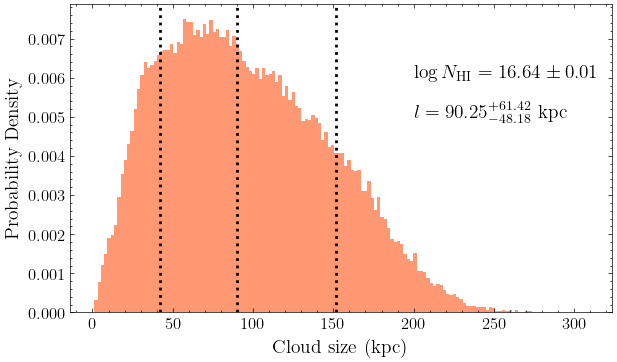

In [71]:
fig, ax = plt.subplots(1, figsize=(7,4))

ax.hist(flat_samples_alpha['cloud_size_pc']/1e+3, bins=150, density=True, color='coral', alpha=.8)
ax.axvline(l_med, linestyle=':', lw=2)
ax.axvline(l_perc_16, linestyle=':', lw=2)
ax.axvline(l_perc_84, linestyle=':', lw=2)

ax.text(200, 0.006, s=r'$\log N_{\mathrm{HI}} = 16.64 \pm 0.01$')
ax.text(200, 0.005, s=r'$l = 90.25_{-48.18}^{+61.42} \ \mathrm{kpc}$')

ax.set_xlabel('Cloud size (kpc)')
ax.set_ylabel('Probability Density')

Save the dataframe again

In [72]:
flat_samples_alpha.to_csv(savedir+'alpha_solar_flat.csv', index=False)